# 📈 Análisis Exploratorio de Ventas Semanales
**Herramientas:** Python · Pandas · Matplotlib  
**Objetivo:** Identificar valores nulos y outliers, calcular correlaciones entre variables y visualizar la relación entre precio y unidades vendidas.


## 1. Importar librerías

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Crear el DataFrame

Creamos el DataFrame a partir de los datos semanales de ventas y convertimos la columna `semana` a formato `datetime`.

In [21]:
data = [
    {"semana": "2023-01-01", "unidades_vendidas": 100, "precio": 8, "publicidad_1": 5, "oferta_1": None},
    {"semana": "2023-01-08", "unidades_vendidas": 200, "precio": 15, "publicidad_1": 8, "oferta_1": 2},
    {"semana": "2023-01-15", "unidades_vendidas": 950, "precio": 11, "publicidad_1": 6, "oferta_1": 3},
    {"semana": "2023-01-22", "unidades_vendidas": 150, "precio": 10, "publicidad_1": 7, "oferta_1": 1},
    {"semana": "2023-01-29", "unidades_vendidas": 1100, "precio": 20, "publicidad_1": 9, "oferta_1": None},
    {"semana": "2023-02-05", "unidades_vendidas": 120, "precio": 12, "publicidad_1": 5, "oferta_1": 2},
    {"semana": "2023-02-12", "unidades_vendidas": 250, "precio": 9, "publicidad_1": 8, "oferta_1": 1},
    {"semana": "2023-02-19", "unidades_vendidas": 300, "precio": 14, "publicidad_1": 7, "oferta_1": None},
    {"semana": "2023-02-26", "unidades_vendidas": 400, "precio": 17, "publicidad_1": 9, "oferta_1": 3},
    {"semana": "2023-03-05", "unidades_vendidas": 150, "precio": 13, "publicidad_1": 5, "oferta_1": 2},
    {"semana": "2023-03-12", "unidades_vendidas": 100, "precio": 10, "publicidad_1": 6, "oferta_1": None},
    {"semana": "2023-03-19", "unidades_vendidas": 500, "precio": 18, "publicidad_1": 10, "oferta_1": 4},
    {"semana": "2023-03-26", "unidades_vendidas": 180, "precio": 16, "publicidad_1": 8, "oferta_1": 2},
    {"semana": "2023-04-02", "unidades_vendidas": 170, "precio": 12, "publicidad_1": 7, "oferta_1": 1},
    {"semana": "2023-04-09", "unidades_vendidas": 1000, "precio": 22, "publicidad_1": 9, "oferta_1": None},
    {"semana": "2023-04-16", "unidades_vendidas": 210, "precio": 11, "publicidad_1": 5, "oferta_1": 3},
    {"semana": "2023-04-23", "unidades_vendidas": 230, "precio": 14, "publicidad_1": 8, "oferta_1": 2},
    {"semana": "2023-04-30", "unidades_vendidas": 190, "precio": 15, "publicidad_1": 6, "oferta_1": 1},
    {"semana": "2023-05-07", "unidades_vendidas": 300, "precio": 16, "publicidad_1": 9, "oferta_1": 4},
    {"semana": "2023-05-14", "unidades_vendidas": 250, "precio": 10, "publicidad_1": 7, "oferta_1": None},
    {"semana": "2023-05-21", "unidades_vendidas": 400, "precio": 17, "publicidad_1": 10, "oferta_1": 3},
    {"semana": "2023-05-28", "unidades_vendidas": 980, "precio": 23, "publicidad_1": 9, "oferta_1": None},
    {"semana": "2023-06-04", "unidades_vendidas": 150, "precio": 12, "publicidad_1": 5, "oferta_1": 2},
    {"semana": "2023-06-11", "unidades_vendidas": 170, "precio": 9, "publicidad_1": 6, "oferta_1": None}
]
df = pd.DataFrame(data)

# Convertimos la columna semana a datetime
df['semana'] = pd.to_datetime(df['semana'])
print(df.dtypes)

semana               datetime64[us]
unidades_vendidas             int64
precio                        int64
publicidad_1                  int64
oferta_1                    float64
dtype: object


## 3. Análisis de valores nulos

Identificamos cuántos valores nulos hay por columna y los rellenamos usando `ffill()` (hacia adelante) y `bfill()` (hacia atrás) para cubrir los casos que `ffill` no pueda resolver.

In [22]:
# Conteo de nulos por columna
print(df.isna().sum())

semana               0
unidades_vendidas    0
precio               0
publicidad_1         0
oferta_1             8
dtype: int64


In [23]:
# Primero rellenamos hacia adelante
df_filled = df.ffill()

# Luego rellenamos hacia atrás (por si el primer valor es nulo)
df_filled = df_filled.bfill()

print("\nDataFrame después de rellenar los nulos:\n", df_filled)


DataFrame después de rellenar los nulos:
        semana  unidades_vendidas  precio  publicidad_1  oferta_1
0  2023-01-01                100       8             5       2.0
1  2023-01-08                200      15             8       2.0
2  2023-01-15                950      11             6       3.0
3  2023-01-22                150      10             7       1.0
4  2023-01-29               1100      20             9       1.0
5  2023-02-05                120      12             5       2.0
6  2023-02-12                250       9             8       1.0
7  2023-02-19                300      14             7       1.0
8  2023-02-26                400      17             9       3.0
9  2023-03-05                150      13             5       2.0
10 2023-03-12                100      10             6       2.0
11 2023-03-19                500      18            10       4.0
12 2023-03-26                180      16             8       2.0
13 2023-04-02                170      12       

## 4. Detección de outliers

Usamos un box plot sobre `unidades_vendidas` para identificar visualmente los valores extremos. Los puntos que aparecen fuera de los bigotes del diagrama son outliers.

<Axes: >

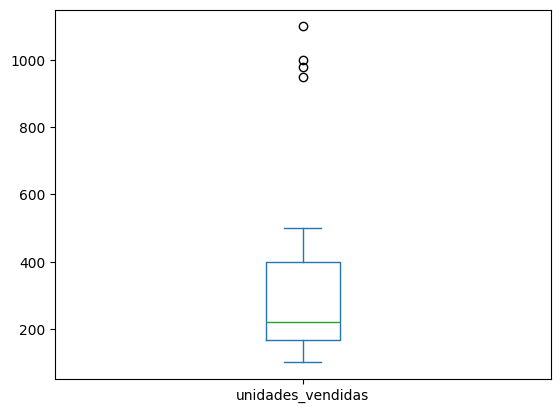

In [24]:
df_filled['unidades_vendidas'].plot.box()

## 5. Correlación de Pearson

Calculamos la correlación de Pearson entre `unidades_vendidas`, `precio` y `publicidad_1` para medir la relación lineal entre estas variables.

In [25]:
subset = df_filled[['unidades_vendidas', 'precio', 'publicidad_1']]
correlation_matrix = subset.corr(method='pearson')
print("Matriz de correlación de Pearson (solo para las tres columnas seleccionadas):")
print(correlation_matrix)

Matriz de correlación de Pearson (solo para las tres columnas seleccionadas):
                   unidades_vendidas    precio  publicidad_1
unidades_vendidas           1.000000  0.695364      0.505473
precio                      0.695364  1.000000      0.722081
publicidad_1                0.505473  0.722081      1.000000


## 6. Gráfico de dispersión

Representamos la relación entre `precio` y `unidades_vendidas`. Los outliers se destacan visualmente al alejarse del grupo principal de puntos.

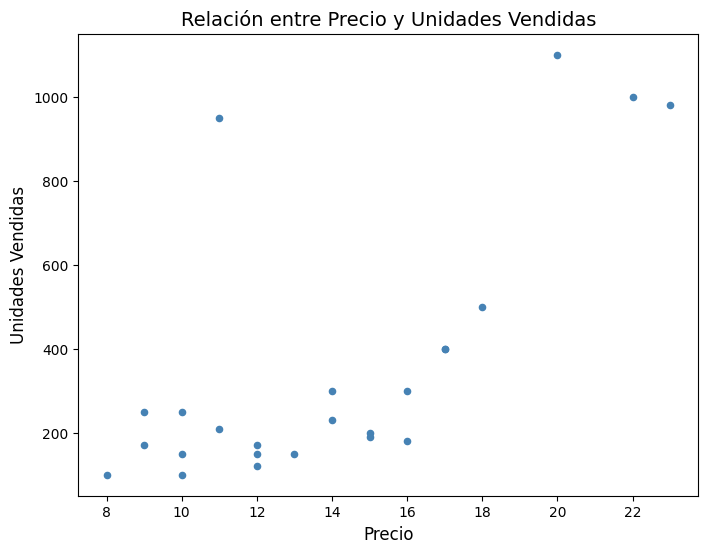

In [26]:
# Gráfico de dispersión usando pandas plot()
ax = df_filled.plot(kind='scatter', x='precio', y='unidades_vendidas', color='steelblue', figsize=(8,6))

# Título del gráfico
ax.set_title('Relación entre Precio y Unidades Vendidas', fontsize=14)

# Etiquetas de los ejes
ax.set_xlabel('Precio', fontsize=12)
ax.set_ylabel('Unidades Vendidas', fontsize=12)

plt.show()